# YOLOv11 Training on Google Colab

此 Notebook 用於在 Google Colab 上訓練 YOLOv11 模型。

## 前置作業
1.  將生成的資料集資料夾 `dataset_train_vaild_test` 壓縮成 `dataset_train_vaild_test.zip`。
2.  將 `dataset_train_vaild_test.zip` 上傳到您的 Google Drive (建議放在根目錄或指定資料夾)。
3.  確認 `data.yaml` 路徑設定正確。

## 1. 安裝 Ultralytics
安裝 YOLOv11 所需的套件。

In [ ]:
%pip install ultralytics
import ultralytics
ultralytics.checks()

Ultralytics 8.3.248 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA A100-SXM4-80GB, 81222MiB)
Setup complete ✅ (12 CPUs, 167.1 GB RAM, 38.5/235.7 GB disk)


In [ ]:
!nvidia-smi

Wed Jan  7 05:48:48 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   33C    P0             54W /  400W |       5MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

## 2. 掛載 Google Drive
以便存取資料集並儲存訓練結果。

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 3. 解壓縮資料集
假設您的資料集位於 Drive 的 `MyDrive/dataset_train_vaild_test.zip`。
我們會將其解壓到 `/content/datasets` 以加快讀取速度。

In [ ]:
# import os
# import zipfile

# # 定義路徑 (請依實際狀況修改)
# zip_path = '/content/drive/MyDrive/Tibame_Project/data_picture/rename_dataset/dataset_train_valid_test.zip'
# extract_path = '/content/drive/MyDrive/Tibame_Project/data_picture/rename_dataset'

# if not os.path.exists(extract_path):
#     os.makedirs(extract_path)

# if os.path.exists(zip_path):
#     print("正在解壓縮...")
#     with zipfile.ZipFile(zip_path, 'r') as zip_ref:
#         zip_ref.extractall(extract_path)
#     print("解壓縮完成！")

#     print(f"\n--- 檢查 '{zip_path}' 壓縮檔內部結構 ---")
#     with zipfile.ZipFile(zip_path, 'r') as zip_ref:
#         for file_info in zip_ref.infolist():
#             print(file_info.filename)

#     print(f"\n--- 列出解壓縮後的目標目錄 '{extract_path}' 內容 ---")
#     if os.path.exists(extract_path):
#         for root, dirs, files in os.walk(extract_path):
#             level = root.replace(extract_path, '').count(os.sep)
#             indent = ' ' * 4 * (level)
#             print(f"{indent}{os.path.basename(root)}/")
#             subindent = ' ' * 4 * (level + 1)
#             for f in files:
#                 print(f"{subindent}{f}")
#     else:
#         print(f"錯誤：解壓縮目錄 '{extract_path}' 不存在。")

# else:
#     print(f"錯誤：找不到檔案 {zip_path}，請檢查路徑。")


## 4. 開始訓練 (Training)
使用 YOLOv11m 進行微調。
請確保 `data` 參數指向解壓後正確的 `data.yaml` 位置。

In [ ]:
import os
import shutil
from ultralytics import YOLO

# --- 步驟 1: 將資料從 Google Drive 複製到 Colab 本地 (大幅加速!) ---
# 來源路徑 (您的雲端硬碟)
source_path = '/content/drive/MyDrive/Tibame_Project/data_picture/rename_dataset/dataset_train_valid_test'
# 目的地路徑 (Colab 的暫存硬碟，關機即消失，讀寫超快)
local_path = '/content/dataset_local'

if not os.path.exists(local_path):
    print("🚀 正在將資料搬移至 Colab 本地磁碟以加速訓練 (約需 2-5 分鐘)...")
    shutil.copytree(source_path, local_path)
    print("✅ 資料搬移完成！")
else:
    print("ℹ️ 本地資料已存在，跳過搬移。")


# --- 步驟 2: 修改 yaml 檔內的路径 ---
# 因為資料搬家了，我們要動態產生一個新的 yaml 指向本地
import yaml

# 讀取原本的 yaml
original_yaml_path = os.path.join(local_path, 'data.yaml')
with open(original_yaml_path, 'r') as f:
    data_config = yaml.safe_load(f)

# 修改路徑指向本地 (使用絕對路徑)
data_config['path'] = local_path
data_config['train'] = 'train/images'
data_config['val'] = 'valid/images'
data_config['test'] = 'test/images'

# 存成新的 yaml
new_yaml_path = '/content/data_local.yaml'
with open(new_yaml_path, 'w') as f:
    yaml.dump(data_config, f)

print(f"📄 新的設定檔已建立: {new_yaml_path}")


# --- 步驟 3: 開始訓練 ---
# 載入模型
model = YOLO('yolo11m.pt')

# 設定資料路徑 (注意：在 Colab 中通常是絕對路徑)
# 假設解壓後結構為 /content/datasets/dataset_train_vaild_test/data.yaml
# 請根據您的 zip 結構調整
yaml_path = '/content/drive/MyDrive/Tibame_Project/data_picture/rename_dataset/dataset_train_valid_test/data.yaml'

# 開始訓練
results = model.train(
    data=yaml_path,
    epochs=50,      # 訓練輪數
    imgsz=640,      # 圖片大小
    batch=64,       # Batch size
    name='tibame_food_model_class99',
    device=0,        # 使用 GPU
    cache=True,     # 儲存訓練結果
    amp=True,       # 禁用自動混合精度，解決 yolo11n.pt 下載失敗問題
    patience=15,
    workers=16,
    exist_ok=True,
    verbose=True
)

🚀 正在將資料搬移至 Colab 本地磁碟以加速訓練 (約需 2-5 分鐘)...
✅ 資料搬移完成！
📄 新的設定檔已建立: /content/data_local.yaml
Ultralytics 8.3.248 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA A100-SXM4-80GB, 81222MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Tibame_Project/data_picture/rename_dataset/dataset_train_valid_test/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m.pt, momentum=0.937, mosai

/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:568: UserWarning: Glyph 38738 (\N{CJK UNIFIED IDEOGRAPH-9752}) missing from font(s) DejaVu Sans.
  fig.savefig(plot_fname, dpi=250)
/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:568: UserWarning: Glyph 27743 (\N{CJK UNIFIED IDEOGRAPH-6C5F}) missing from font(s) DejaVu Sans.
  fig.savefig(plot_fname, dpi=250)
/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:568: UserWarning: Glyph 33756 (\N{CJK UNIFIED IDEOGRAPH-83DC}) missing from font(s) DejaVu Sans.
  fig.savefig(plot_fname, dpi=250)
/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:568: UserWarning: Glyph 35948 (\N{CJK UNIFIED IDEOGRAPH-8C6C}) missing from font(s) DejaVu Sans.
  fig.savefig(plot_fname, dpi=250)
/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:568: UserWarning: Glyph 32905 (\N{CJK UNIFIED IDEOGRAPH-8089}) missing from font(s) DejaVu Sans.
  fig.savefig(plot_fname, dpi=

                   all       1039       7218      0.731      0.692      0.731      0.587
                   青江菜          2         20      0.633        0.5      0.509      0.196
                     鹽          1         22      0.227     0.0909      0.118     0.0727
                    豬肉         42         74      0.838      0.489      0.647      0.416
                澱粉/太白粉          3          5      0.165        0.2       0.34      0.307
                    米酒          7         12      0.953          1      0.995      0.945
                    蒜頭         54         67      0.967          1      0.995      0.938
                     水          7         10      0.654        0.7      0.745       0.51
                     薑          7        100      0.806      0.624      0.756      0.566
                    雞肉         38         55      0.874      0.891      0.953      0.869
                   胡椒粉          3          5      0.557          1      0.995      0.603
                     

## 5. 備份模型權重、熱力圖、混淆矩陣
訓練完成後，將最佳權重複製回 Google Drive 以免 Colab 關閉後遺失。

In [ ]:
!pip install grad-cam opencv-python matplotlib
# 1. 安裝中文字型 (思源黑體)
!apt-get -y install fonts-noto-cjk

# 2. 清除 Matplotlib 的快取 (確保它能讀到新字型)
import matplotlib as mpl
import matplotlib.pyplot as plt
!rm -rf ~/.cache/matplotlib

# 3. 設定中文字型
plt.rcParams['font.sans-serif'] = ['Noto Sans CJK JP'] # 使用剛安裝的字型
plt.rcParams['axes.unicode_minus'] = False            # 解決負號顯示問題


📍 鎖定最新的訓練資料夾: /content/runs/detect/tibame_food_model_class99

📊 [Phase 1] 分析訓練成效...

📈 訓練圖表速覽:
  - Confusion Matrix


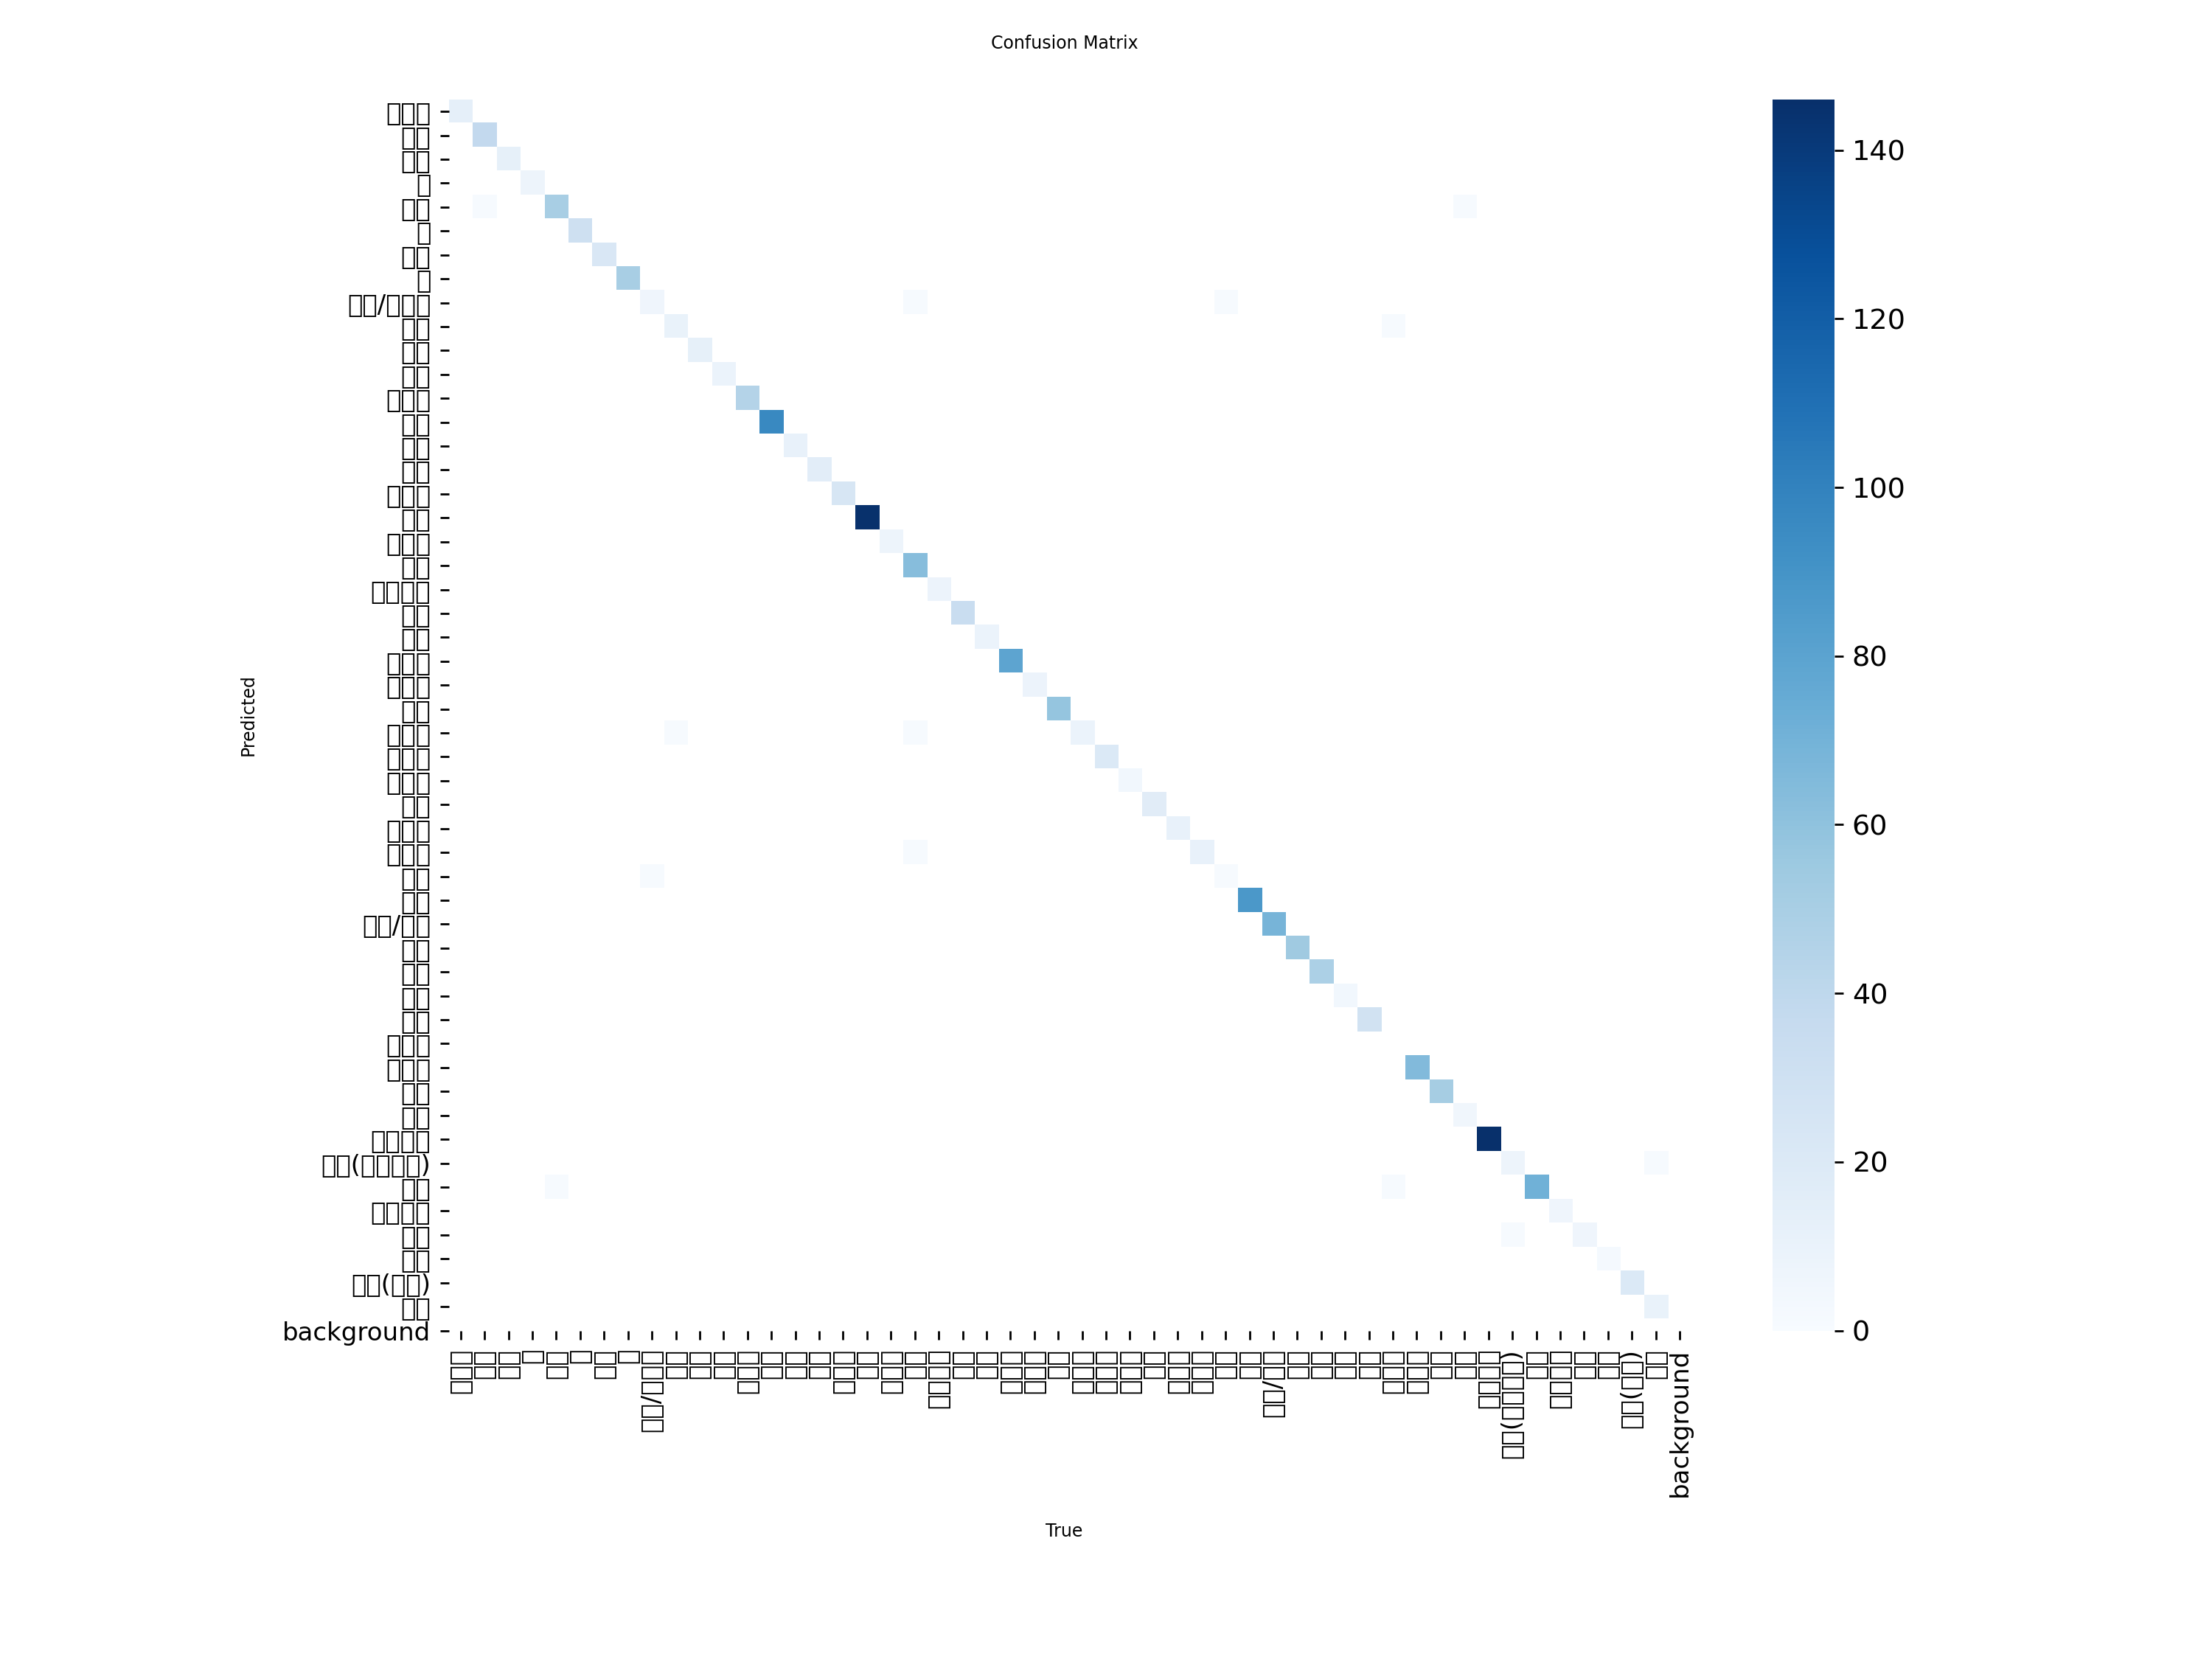

  - Results


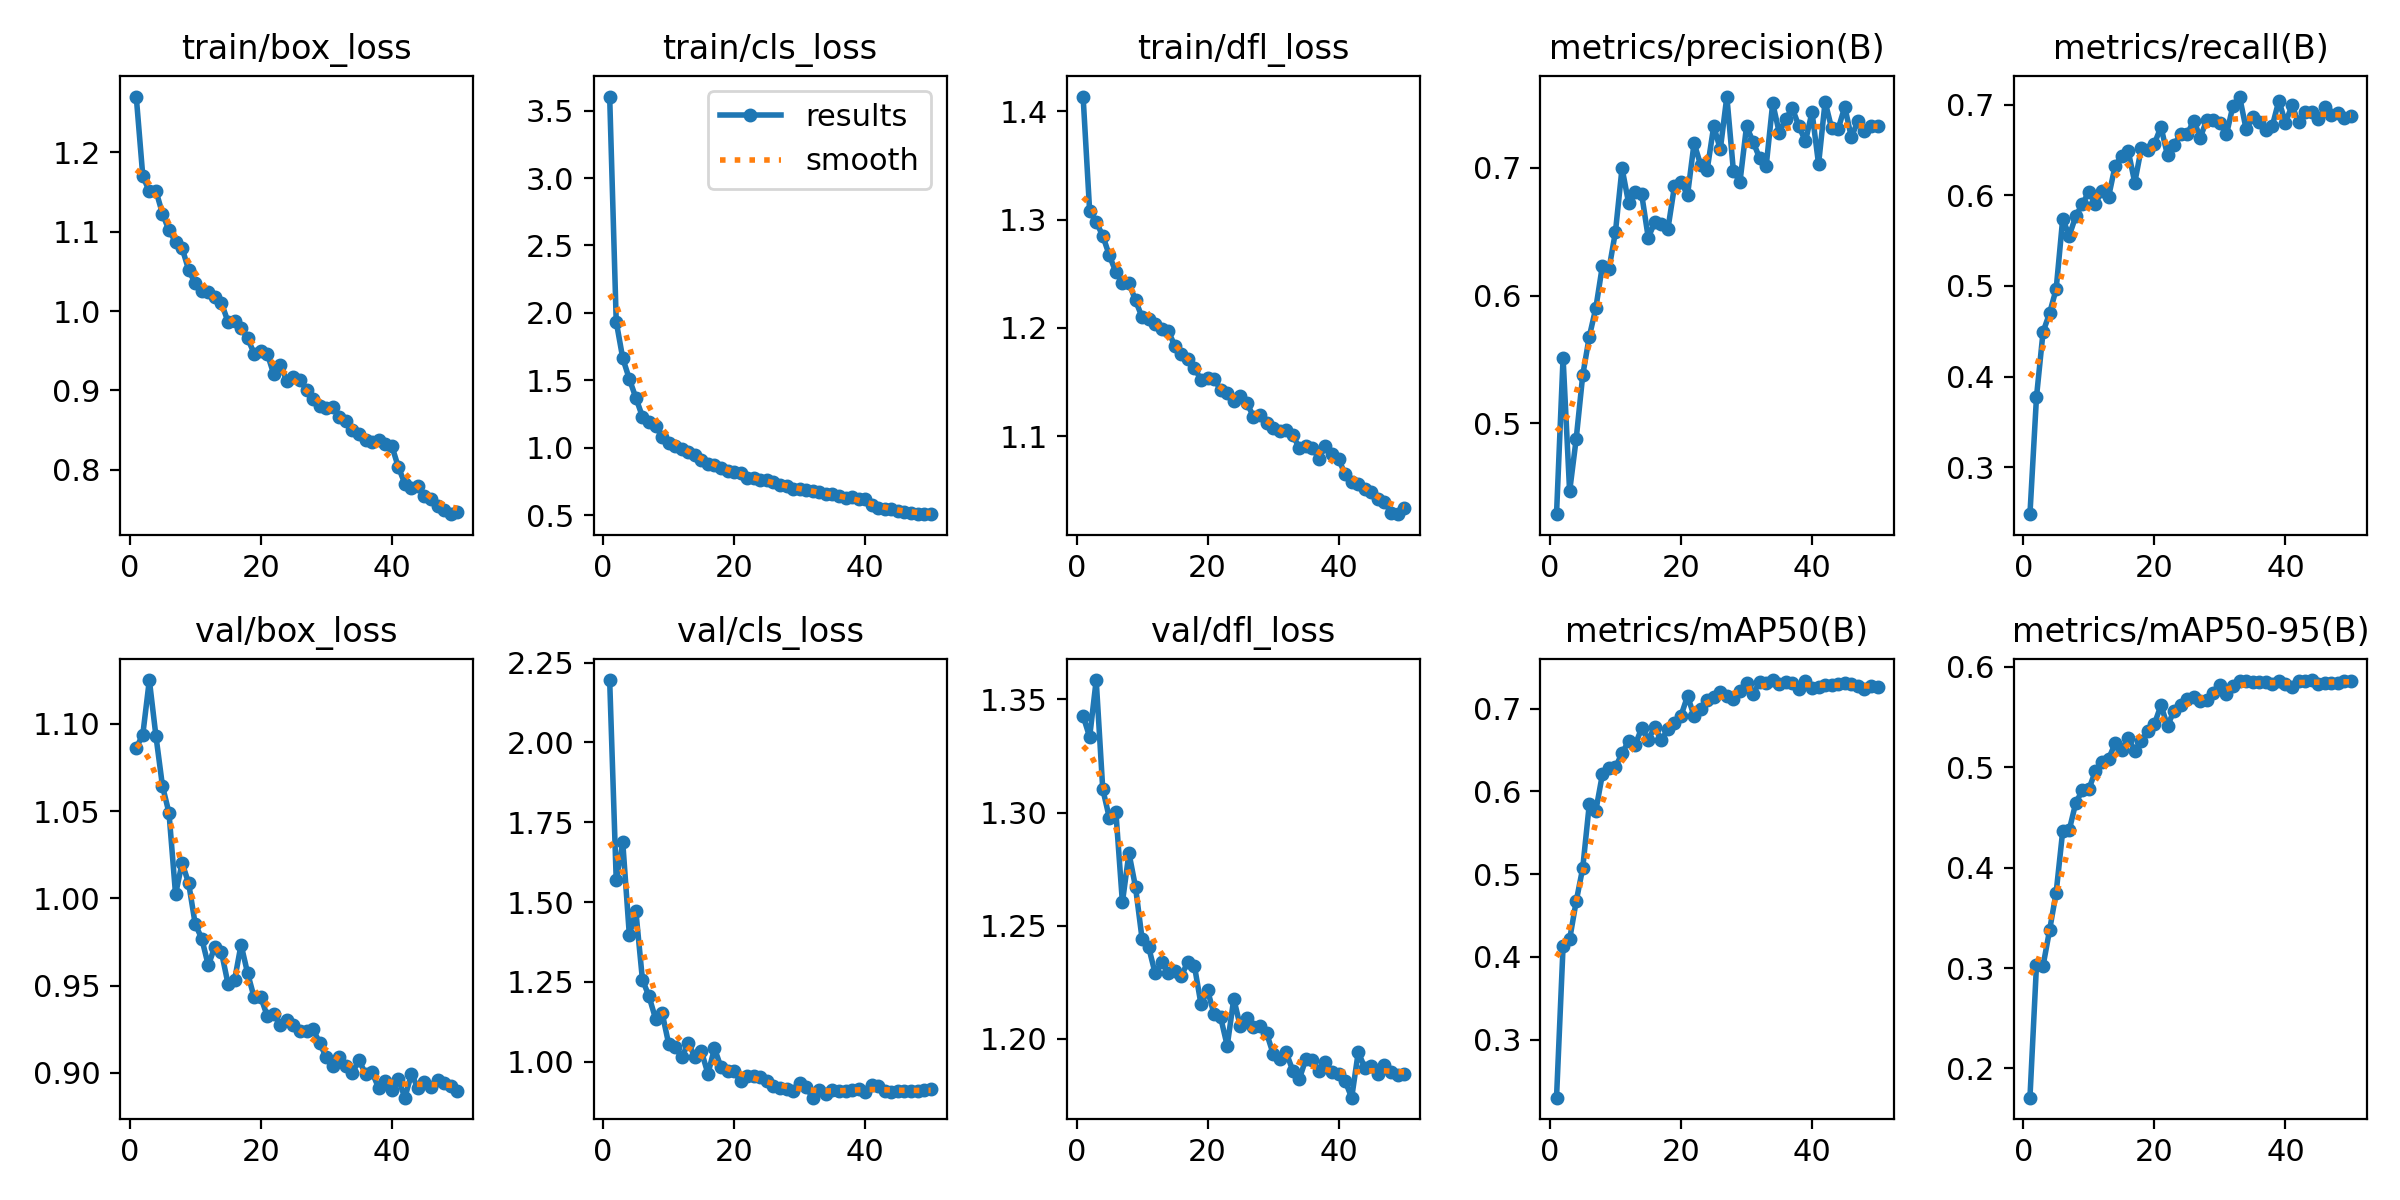


🔥 [Phase 2] 生成熱力圖 (每類抽 5 張)...
找到 1039 個標籤檔案，開始比對圖片...
✅ 成功分類圖片，共有 97 個類別有圖片。


生成熱力圖: 100%|██████████| 97/97 [06:55<00:00,  4.29s/it]


✅ 熱力圖生成完畢，共 0 張。

📦 [Phase 3] 執行雲端備份...
✅ 備份大成功！
📂 備份路徑: /content/drive/MyDrive/Tibame_Project/model/model_backups/yolo11m_mAP0.735_Class101_Epoch50_20260107_1726
內容包含：
 1. best.pt 權重
 2. 訓練圖表 (F1, Confusion Matrix)
 3. 熱力圖資料夾 (heatmaps_analysis)


In [ ]:
import os
import glob
import shutil
import datetime
import yaml
import pandas as pd
import cv2
import numpy as np
import torch
import random
from IPython.display import display, Image
from ultralytics import YOLO
from pytorch_grad_cam import EigenCAM
from pytorch_grad_cam.utils.image import show_cam_on_image, preprocess_image
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib as mpl

# 設定中文字型 (請確保已執行過上面的 apt-get 安裝指令)
mpl.rc('font', family='Noto Sans CJK JP')
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# 🛠️ 參數設定區 (Configuration)
# ==========================================
# 1. 備份目的地 (Google Drive)
backup_root = '/content/drive/MyDrive/Tibame_Project/model/model_backups'

# 2. 資料集路徑 (用於生成熱力圖，請指向包含 valid/images 的資料夾)
# 如果您之前有搬到 local，這裡可以改 /content/dataset_local
dataset_root = '/content/drive/MyDrive/Tibame_Project/data_picture/rename_dataset/dataset_train_valid_test'

# 3. 熱力圖設定
target_split = 'valid'  # 使用驗證集來測試
images_per_class = 5    # 每個類別抽幾張圖來畫熱力圖 (建議 5-10 張)

# ==========================================

# 建立備份根目錄
if not os.path.exists(backup_root):
    os.makedirs(backup_root)

# --- 1. 自動搜尋最新的訓練結果 ---
found_files = glob.glob('/content/runs/detect/**/weights/best.pt', recursive=True)

if not found_files:
    print("❌ 錯誤：找不到 best.pt，請確認訓練是否完成。")
else:
    # 抓最新的 best.pt
    best_weight_path = max(found_files, key=os.path.getmtime)
    exp_dir = os.path.dirname(os.path.dirname(best_weight_path))
    print(f"📍 鎖定最新的訓練資料夾: {exp_dir}")

    # ==========================================
    #   PART A: 訓練數據分析與圖表檢視
    # ==========================================
    print("\n📊 [Phase 1] 分析訓練成效...")

    # 1. 讀取 mAP50
    csv_path = os.path.join(exp_dir, 'results.csv')
    best_map50 = 0.0
    if os.path.exists(csv_path):
        try:
            df = pd.read_csv(csv_path)
            df.columns = [c.strip() for c in df.columns]
            if 'metrics/mAP50(B)' in df.columns:
                best_map50 = df['metrics/mAP50(B)'].max()
        except:
            pass

    # 2. 讀取 Epoch 和 Model 型號
    yaml_path = os.path.join(exp_dir, 'args.yaml')
    epochs = 0
    model_type = "yolov11"
    if os.path.exists(yaml_path):
        with open(yaml_path, 'r') as f:
            args = yaml.safe_load(f)
            epochs = args.get('epochs', 0)
            model_file = args.get('model', 'yolov11')
            if isinstance(model_file, str):
                model_type = os.path.splitext(os.path.basename(model_file))[0]

    # 3. 在 Colab 顯示關鍵圖表
    print("\n📈 訓練圖表速覽:")
    target_images = {
        'F1 Curve': 'F1_curve.png',
        'Confusion Matrix': 'confusion_matrix.png',
        'Results': 'results.png'
    }
    for title, filename in target_images.items():
        img_path = os.path.join(exp_dir, filename)
        if os.path.exists(img_path):
            print(f"  - {title}")
            display(Image(filename=img_path, width=500))

    # ==========================================
    #   PART B: 生成熱力圖 (Heatmaps)
    # ==========================================
    print(f"\n🔥 [Phase 2] 生成熱力圖 (每類抽 {images_per_class} 張)...")

    # 定義熱力圖輸出位置 (直接放在訓練結果資料夾內，方便一起備份)
    heatmap_output_dir = os.path.join(exp_dir, 'heatmaps_analysis')
    os.makedirs(heatmap_output_dir, exist_ok=True)

    # 載入模型
    model_wrapper = YOLO(best_weight_path)
    model = model_wrapper.model
    names = model_wrapper.names
    nc = len(names) # 順便取得類別數

    # 尋找目標層 (C2f)
    target_layers = [module for module in model.modules() if module.__class__.__name__ == 'C2f']
    if not target_layers: target_layers = [model.model[-2]]

    # 初始化 CAM
    cam = EigenCAM(model=model, target_layers=[target_layers[-1]])

    # 取得圖片列表
    image_dir = os.path.join(dataset_root, target_split, 'images')
    label_dir = os.path.join(dataset_root, target_split, 'labels')

    # 掃描並分類圖片
    # 掃描圖片 (強化版)
    image_dir = os.path.join(dataset_root, target_split, 'images')
    label_dir = os.path.join(dataset_root, target_split, 'labels')
    class_img_map = {}

    if not os.path.exists(label_dir):
        print(f"❌ 找不到標籤資料夾: {label_dir}")
    else:
        txt_files = glob.glob(os.path.join(label_dir, '*.txt'))
        print(f"找到 {len(txt_files)} 個標籤檔案，開始比對圖片...")

        for txt in txt_files:
            try:
                with open(txt, 'r') as f:
                    lines = f.readlines()
                    if not lines: continue
                    cls_id = int(lines[0].split()[0]) # 抓第一個物件的類別

                    # 嘗試多種副檔名
                    base_name = os.path.splitext(os.path.basename(txt))[0]
                    img_path = None
                    for ext in ['.jpg', '.JPG', '.png', '.PNG', '.jpeg']:
                        test_p = os.path.join(image_dir, base_name + ext)
                        if os.path.exists(test_p):
                            img_path = test_p
                            break

                    if img_path:
                        if cls_id not in class_img_map: class_img_map[cls_id] = []
                        class_img_map[cls_id].append(img_path)
            except Exception as e:
                continue

    if not class_img_map:
        print("❌ 警告： class_img_map 是空的！請檢查 images 和 labels 的檔名是否對應。")
    else:
        print(f"✅ 成功分類圖片，共有 {len(class_img_map)} 個類別有圖片。")

    # 開始生成
    processed_count = 0
    for cls_id in tqdm(sorted(class_img_map.keys()), desc="生成熱力圖"):
        cls_name = names[cls_id]
        img_paths = class_img_map[cls_id]
        selected = random.sample(img_paths, min(len(img_paths), images_per_class))

        save_cls_dir = os.path.join(heatmap_output_dir, f"{cls_id}_{cls_name}")
        os.makedirs(save_cls_dir, exist_ok=True)

        for img_p in selected:
            try:
                img = cv2.imread(img_p)
                if img is None: continue
                img = cv2.resize(img, (640, 640))
                rgb_img = np.float32(img) / 255
                tensor = preprocess_image(rgb_img, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]).to(next(model.parameters()).device)

                grayscale_cam = cam(input_tensor=tensor)[0, :]
                visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

                cv2.imwrite(os.path.join(save_cls_dir, os.path.basename(img_p)), cv2.cvtColor(visualization, cv2.COLOR_RGB2BGR))
                processed_count += 1
            except: pass

    print(f"✅ 熱力圖生成完畢，共 {processed_count} 張。")

    # ==========================================
    #   PART C: 智慧打包備份
    # ==========================================
    print("\n📦 [Phase 3] 執行雲端備份...")

    # 組合資料夾名稱
    tz_taiwan = datetime.timezone(datetime.timedelta(hours=8))
    timestamp = datetime.datetime.now(tz_taiwan).strftime("%Y%m%d_%H%M")

    map_str = f"{best_map50:.3f}"
    folder_name = f"{model_type}_mAP{map_str}_Class{nc}_Epoch{epochs}_{timestamp}"

    dest_dir = os.path.join(backup_root, folder_name)

    try:
        if os.path.exists(dest_dir):
            shutil.rmtree(dest_dir)

        # 複製整個目錄 (含 weights, plots, results.csv, heatmaps_analysis)
        shutil.copytree(exp_dir, dest_dir)

        print(f"✅ 備份大成功！")
        print(f"📂 備份路徑: {dest_dir}")
        print(f"內容包含：\n 1. best.pt 權重\n 2. 訓練圖表 (F1, Confusion Matrix)\n 3. 熱力圖資料夾 (heatmaps_analysis)")

    except Exception as e:
        print(f"❌ 備份失敗: {e}")